# Week 6: Building a Baseline Model (Part 2 of 2)

This notebook uses the `triage_cleaned_v1.csv` dataset, which is a product of the `Week5_DataExploration.ipynb` notebook. It is used in this notebook to train and test 3 baseline models: a dummy classifier, a logistic regression model, and a decision tree model. The goal is to accurately predict the ESI (Emergency Severity Index) levels of ED patients.

## 1. Setup

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

pd.set_option("display.width", 120)
print("Libraries loaded. ✅")

Libraries loaded. ✅


In [29]:
df = pd.read_csv("triage_cleaned_v1.csv")
print("Dataset successfully loaded:", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Dataset successfully loaded: 55121 patients and 225 columns.


,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Prepare the features (X) and target (y)

### 2.1 Grouping of columns into categories for modelling purposes

In [30]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]

# Who the patient is:
NUMERICAL_DEMOGRAPHICS = ["age"]

CATEGORICAL_DEMOGRAPHICS = ["gender", "ethnicity", "race", "lang", "religion", 
                            "maritalstatus", "employstatus", "insurance_status"]

# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN]

In [31]:
X = df[FEATURES]
y = df[TARGET]

print("Number of features before one-hot encoding:", len(FEATURES))
print("Model will use features to predict:", TARGET)
print("First few features:", FEATURES[:10], "...")

Number of features before one-hot encoding: 217
Model will use features to predict: esi
First few features: ['age', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'triage_vital_hr'] ...


### 2.2 One-hot encoding of categorical demographic features

Our models can only handle numerical data. Thus, our non-numerical data (categorical demographics) needs to be converted. We achieve this through one-hot encoding.

In [32]:
encoder = OneHotEncoder(
    handle_unknown="ignore", # prevents errors if the test set contains categories not seen during training.
    sparse_output=False # returns a regular NumPy array instead of a sparse matrix
)

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, CATEGORICAL_DEMOGRAPHICS)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [34]:
X_processed = preprocessor.fit_transform(X)

In [35]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features after one-hot encoding:", len(feature_names))
print("First few features:", feature_names[:10], "...")

Number of features after one-hot encoding: 262
First few features: ['gender_Female' 'gender_Male' 'ethnicity_Hispanic or Latino'
 'ethnicity_Non-Hispanic' 'ethnicity_Patient Refused' 'ethnicity_Unknown'
 'race_American Indian or Alaska Native' 'race_Asian'
 'race_Black or African American'
 'race_Native Hawaiian or Other Pacific Islander'] ...


### 2.3 Split into training and test sets

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, stratify=y, random_state=42)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


## 3. Baseline Models

### 3.1 Dummy Classifier

In [ ]:
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
print(round(dummy.score(X_test, y_test) * 100, 2), "% accuracy on the test set.")

37.54 % accuracy on the test set.


### 3.2 Logistic Regression

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_score = logreg.score(X_test_scaled, y_test)
print(round(logreg_score * 100, 2), "% accuracy on the test set.")

68.0 % accuracy on the test set.


### 3.3 Decision Tree

In [51]:
tree = DecisionTreeClassifier(max_depth=15, random_state=42)
tree.fit(X_train, y_train)
print(round(tree.score(X_test, y_test) * 100, 2), "% accuracy on the test set.")

59.35 % accuracy on the test set.


The max_depth hyperparameter was selected by comparing model performance across several candidate values (5, 10, 15, and 20). Test accuracy increased substantially up to a depth of 15 (54.74% → 59.35%), but only marginally thereafter (59.45% at a depth of 20). Since the additional 0.10 percentage point improvement did not justify the increased model complexity and greater risk of overfitting, a maximum depth of 15 was chosen as the best trade-off between predictive performance and model complexity.

## 4. Model Evaluation

### 4.1 Accuracy, Precision, Recall, and F1

In [54]:
pred_dummy = dummy.predict(X_test)
print("Dummy Classifier Classification Report:\n", classification_report(y_test, pred_dummy))

Dummy Classifier Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.33      0.33      0.33      3585
           3       0.49      0.50      0.49      5402
           4       0.15      0.15      0.15      1779
           5       0.05      0.05      0.05       243

    accuracy                           0.38     11025
   macro avg       0.20      0.20      0.20     11025
weighted avg       0.37      0.38      0.37     11025



In [52]:
pred_logreg = logreg.predict(X_test_scaled)
print("Logistic Regression Classification Report:\n", classification_report(y_test, pred_logreg))

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.73      0.63      0.67      3585
           3       0.68      0.76      0.72      5402
           4       0.62      0.61      0.62      1779
           5       0.43      0.14      0.22       243

    accuracy                           0.68     11025
   macro avg       0.58      0.48      0.51     11025
weighted avg       0.68      0.68      0.68     11025



In [53]:
pred_tree = tree.predict(X_test)
print("Decision Tree Classification Report:\n", classification_report(y_test, pred_tree))

Decision Tree Classification Report:
               precision    recall  f1-score   support

           1       0.22      0.12      0.16        16
           2       0.74      0.44      0.55      3585
           3       0.56      0.89      0.68      5402
           4       0.65      0.10      0.18      1779
           5       0.00      0.00      0.00       243

    accuracy                           0.59     11025
   macro avg       0.43      0.31      0.31     11025
weighted avg       0.62      0.59      0.54     11025



### 4.2 Confusion Matrix

In [59]:
Path("figs").mkdir(exist_ok=True)

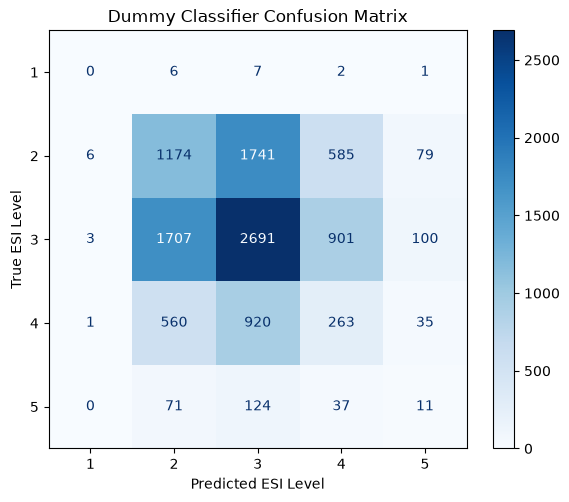

In [64]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_dummy, ax=ax, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Dummy Classifier Confusion Matrix")
plt.tight_layout()
plt.savefig("figs/dummy_classifier_confusion_matrix.png", dpi=150)
plt.show()

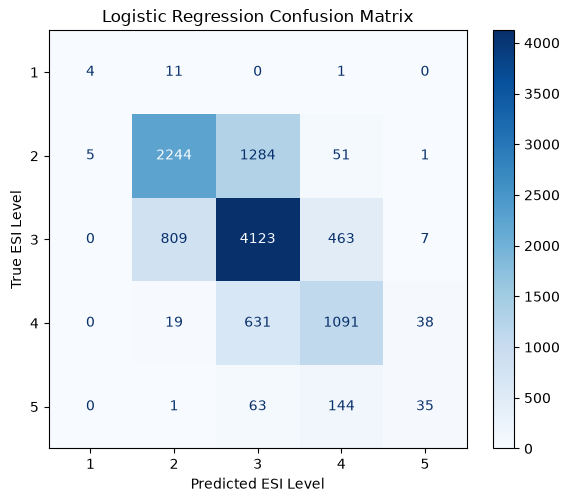

In [65]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, ax=ax, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.savefig("figs/logistic_regression_confusion_matrix.png", dpi=150)
plt.show()

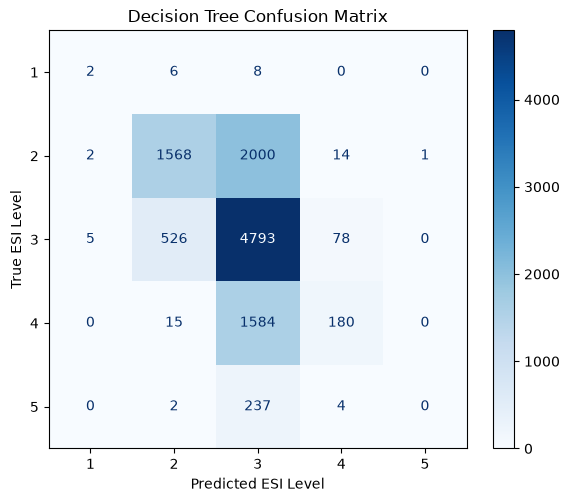

In [66]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tree, ax=ax, cmap=plt.cm.Blues)
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.savefig("figs/decision_tree_confusion_matrix.png", dpi=150)
plt.show()

### 4.3 Macro vs Weighted F1 Score

In [68]:
macro_f1 = f1_score(y_test, pred_dummy, average="macro")
weighted_f1 = f1_score(y_test, pred_dummy, average="weighted")
print("Dummy Classifier F1 Scores:")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Dummy Classifier F1 Scores:
Macro F1: 0.204
Weighted F1: 0.375


In [ ]:
macro_f1 = f1_score(y_test, pred_logreg, average="macro")
weighted_f1 = f1_score(y_test, pred_logreg, average="weighted")
print("Logistic Regression F1 Scores:")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Logistic Regression F1 Scores:
Macro F1: 0.509
Weighted F1: 0.675


In [69]:
macro_f1 = f1_score(y_test, pred_tree, average="macro")
weighted_f1 = f1_score(y_test, pred_tree, average="weighted")
print("Decision Tree F1 Scores:")
print(f"Macro F1: {macro_f1:.3f}")
print(f"Weighted F1: {weighted_f1:.3f}")

Decision Tree F1 Scores:
Macro F1: 0.314
Weighted F1: 0.542
